## Tree-Based Models — Classification (`Demand_Category`)

This notebook evaluates tree-based classifiers for predicting hourly demand category (Low / Normal / High)
using the same evaluation harness developed for the linear baseline: four dataset-cleaning variants
(`train`, `train_preserved_imputed`, `train_clean_imputed`, `train_clean`), five feature-engineering stages
(baseline → skew transforms → weather categories → +Weekday → cyclical time), and `StratifiedKFold(5)`
cross-validated macro-F1 throughout, so results are directly comparable to the logistic-regression baseline.

Four model families are compared — **Random Forest, XGBoost, LightGBM, CatBoost** — each using the categorical
handling most natural to it rather than forcing a single common preprocessing path:

- **Random Forest** goes through an imputer + one-hot `ColumnTransformer`, since it cannot consume raw NaNs or
  raw categorical columns directly.
- **XGBoost / LightGBM / CatBoost** use their own native categorical handling (pandas `category` dtype for
  XGBoost/LightGBM, string `cat_features` for CatBoost) — no manual encoding step needed.

A further comparison isolates the value of native missing-value handling specifically: XGBoost and LightGBM are
additionally evaluated directly on `train_clean_nan` and `train_preserved_nan` — datasets with real, un-imputed
missing values — since both models route missing values internally during tree construction. Random Forest and
CatBoost are not part of that particular comparison (Random Forest cannot consume raw NaN at all).


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (required to unlock IterativeImputer)
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

df_train = pd.read_csv("train.csv")
df_train_preserved_imputed = pd.read_csv("train_preserved_imputed.csv")
df_train_clean_imputed = pd.read_csv("train_clean_imputed.csv")
df_train_clean = pd.read_csv("train_clean.csv")

# Raw-NaN datasets — used only for XGBoost / LightGBM (native missing-value support).
df_train_clean_nan = pd.read_csv("train_clean_nan.csv")
df_train_preserved_nan = pd.read_csv("train_preserved_nan.csv")


In [2]:
# ============================================================
# COMMON CONFIGURATION
# ============================================================

TARGET = "Demand_Category"

DATASETS = {
    "train": df_train.copy(),
    "train_preserved_imputed": df_train_preserved_imputed.copy(),
    "train_clean_imputed": df_train_clean_imputed.copy(),
    "train_clean": df_train_clean.copy(),
}

# Only fed to XGBoost / LightGBM (see markdown above) — raw NaNs, no imputation step at all.
NAN_NATIVE_DATASETS = {
    "train_clean_nan": df_train_clean_nan.copy(),
    "train_preserved_nan": df_train_preserved_nan.copy(),
}

BASE_NUMERIC_FEATURES = [
    "Hour",
    "Temperature",
    "Humidity",
    "Wind speed",
    "Visibility",
    "Dew point temperature",
    "Solar Radiation",
    "Rainfall",
    "Snowfall",
]

BASE_CATEGORICAL_FEATURES = [
    "Seasons",
    "Holiday",
    "Functioning Day",
]

WEATHER_NUMERIC_FEATURES = [
    "Wind speed",
    "Solar Radiation",
    "Rainfall",
    "Snowfall",
    "Visibility",
]

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

TREE_MODELS = ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]
NAN_NATIVE_MODELS = ["XGBoost", "LightGBM"]


In [3]:
def build_preprocessor(numeric_features, categorical_features, X_columns):
    """
    Preprocessing pipeline for Random Forest (identical to the one used in
    logistic_regression.ipynb).

    Numerical:
        Iterative imputation -> standardization

    Categorical:
        Most-frequent imputation -> one-hot encoding
    """

    num_cols = [
        col for col in numeric_features
        if col in X_columns
    ]

    cat_cols = [
        col for col in categorical_features
        if col in X_columns
    ]

    numerical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                IterativeImputer(
                    max_iter=10,
                    random_state=42
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numerical_transformer,
                num_cols
            ),
            (
                "cat",
                categorical_transformer,
                cat_cols
            )
        ],
        remainder="drop"
    )

    return preprocessor


In [4]:
# ============================================================
# FEATURE ENGINEERING (identical to logistic_regression.ipynb)
# ============================================================

def add_skew_transformations(df):
    """
    Add transformed versions of skewed weather variables.
    Original variables are retained.
    """

    out = df.copy()

    right_skewed = [
        "Wind speed",
        "Solar Radiation",
        "Rainfall",
        "Snowfall"
    ]

    for col in right_skewed:
        if col in out.columns:
            # Negative values are physically invalid for these variables.
            # Turn them into NaN so the pipeline can impute them.
            values = out[col].mask(out[col] < 0)
            out[f"{col}_log1p"] = np.log1p(values)

    if "Visibility" in out.columns:
        values = out["Visibility"].mask(out["Visibility"] < 0)
        out["Visibility_pow3"] = values ** 3

    return out


def add_weather_categories(df):
    """
    Add categorical versions of heavily skewed weather variables.
    Original continuous features are retained.
    """

    out = df.copy()

    if "Visibility" in out.columns:
        bins = [-np.inf, 500, 1500, np.inf]
        out["Visibility_Cat"] = pd.cut(
            out["Visibility"], bins=bins, labels=["low", "medium", "high"]
        )

    if "Solar Radiation" in out.columns:
        bins = [-np.inf, 0.1, 1.5, np.inf]
        out["Solar_Radiation_Cat"] = pd.cut(
            out["Solar Radiation"], bins=bins, labels=["none", "low", "high"]
        )

    if "Rainfall" in out.columns:
        bins = [-np.inf, 0.1, 2.0, np.inf]
        out["Rainfall_Cat"] = pd.cut(
            out["Rainfall"], bins=bins, labels=["none", "light", "heavy"]
        )

    if "Snowfall" in out.columns:
        bins = [-np.inf, 0.1, 1.0, np.inf]
        out["Snowfall_Cat"] = pd.cut(
            out["Snowfall"], bins=bins, labels=["none", "light", "heavy"]
        )

    return out


def add_weekday(df):
    """Add weekday derived from Date. Monday = 0, Sunday = 6."""

    out = df.copy()

    if "Date" in out.columns:
        date_parsed = pd.to_datetime(out["Date"], dayfirst=True, errors="coerce")
        out["Weekday"] = date_parsed.dt.dayofweek

    return out


def add_month(df):
    out = df.copy()

    if "Date" in out.columns:
        date_parsed = pd.to_datetime(out["Date"], dayfirst=True, errors="coerce")
        out["Month"] = date_parsed.dt.month

    return out


def add_all_cyclic_time_features(df):
    """Add cyclic representations for Hour, Weekday, Month, Seasons."""

    out = df.copy()

    if "Hour" in out.columns:
        out["Hour_sin"] = np.sin(2 * np.pi * out["Hour"] / 24)
        out["Hour_cos"] = np.cos(2 * np.pi * out["Hour"] / 24)

    if "Weekday" in out.columns:
        out["Weekday_sin"] = np.sin(2 * np.pi * out["Weekday"] / 7)
        out["Weekday_cos"] = np.cos(2 * np.pi * out["Weekday"] / 7)

    if "Month" in out.columns:
        out["Month_sin"] = np.sin(2 * np.pi * (out["Month"] - 1) / 12)
        out["Month_cos"] = np.cos(2 * np.pi * (out["Month"] - 1) / 12)

    if "Seasons" in out.columns:
        season_mapping = {"Winter": 0, "Spring": 1, "Summer": 2, "Autumn": 3}
        season_num = out["Seasons"].map(season_mapping)
        out["Season_sin"] = np.sin(2 * np.pi * season_num / 4)
        out["Season_cos"] = np.cos(2 * np.pi * season_num / 4)

    return out


SKEW_NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + [
    "Wind speed_log1p",
    "Solar Radiation_log1p",
    "Rainfall_log1p",
    "Snowfall_log1p",
    "Visibility_pow3",
]

WEATHER_CATEGORY_FEATURES = BASE_CATEGORICAL_FEATURES + [
    "Visibility_Cat",
    "Solar_Radiation_Cat",
    "Rainfall_Cat",
    "Snowfall_Cat",
]


In [5]:
def evaluate_tree_model(df, numeric_features, categorical_features, model_name, experiment_name=""):
    """
    Evaluate a single tree-based classifier using the same Stratified 5-fold
    CV / macro-F1 harness as evaluate_logistic_regression().

    Categorical handling matches the regression tree_models.ipynb pattern:
      - CatBoost:            categoricals as strings, native cat_features.
      - XGBoost / LightGBM:  categoricals as pandas 'category' dtype
                              (native categorical + native NaN support).
      - RandomForest:        goes through build_preprocessor() (imputer + one-hot),
                              since sklearn's RandomForestClassifier cannot
                              consume raw NaN or raw categoricals.
    """

    feature_cols = [c for c in numeric_features + categorical_features if c in df.columns]
    cat_cols = [c for c in categorical_features if c in df.columns]

    X = df[feature_cols].copy()
    y = df[TARGET].astype(int)

    fold_scores = []

    for train_idx, val_idx in CV.split(X, y):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        if model_name == "CatBoost":

            X_train = X_train.copy()
            X_val = X_val.copy()

            for col in cat_cols:
                X_train[col] = (
                    X_train[col]
                    .astype("string")
                    .fillna("MISSING")
                )

                X_val[col] = (
                    X_val[col]
                    .astype("string")
                    .fillna("MISSING")
                )

            model = CatBoostClassifier(
                random_state=42,
                verbose=False,
                loss_function="MultiClass"
            )

            model.fit(
                X_train,
                y_train,
                cat_features=cat_cols
            )

            preds = (
                model.predict(X_val)
                .astype(int)
                .ravel()
            )

        elif model_name in ("XGBoost", "LightGBM"):
            for col in cat_cols:
                X_train[col] = X_train[col].astype("category")
                X_val[col] = X_val[col].astype("category")

            if model_name == "XGBoost":
                model = XGBClassifier(
                    objective="multi:softmax",
                    num_class=3,
                    enable_categorical=True,
                    tree_method="hist",
                    random_state=42,
                    n_jobs=-1
                )
            else:
                model = LGBMClassifier(
                    random_state=42,
                    n_jobs=-1,
                    verbose=-1
                )

            model.fit(X_train, y_train)
            preds = model.predict(X_val)

        elif model_name == "RandomForest":
            preprocessor = build_preprocessor(numeric_features, categorical_features, X.columns)
            model = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
                ]
            )
            model.fit(X_train, y_train)
            preds = model.predict(X_val)

        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        fold_scores.append(f1_score(y_val, preds, average="macro"))

    fold_scores = np.array(fold_scores)

    result = {
        "Model": model_name,
        "Experiment": experiment_name,
        "Mean Macro F1": fold_scores.mean(),
        "Std Macro F1": fold_scores.std(),
        "Fold 1": fold_scores[0],
        "Fold 2": fold_scores[1],
        "Fold 3": fold_scores[2],
        "Fold 4": fold_scores[3],
        "Fold 5": fold_scores[4],
    }

    print(
        f"[{model_name:<12}] {experiment_name:<50} "
        f"Macro-F1 = {fold_scores.mean():.4f} (± {fold_scores.std():.4f})"
    )

    return result


In [6]:
results = []

for dataset_name, original_df in DATASETS.items():

    print("\n")
    print("=" * 90)
    print(f"DATASET: {dataset_name}")
    print("=" * 90)

    # --------------------------------------------------------
    # 1. GIVEN DATASET / BASELINE
    # --------------------------------------------------------

    df_exp = original_df.copy()

    for model_name in TREE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=BASE_NUMERIC_FEATURES,
                categorical_features=BASE_CATEGORICAL_FEATURES,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 1. Baseline"
            )
        )

    # --------------------------------------------------------
    # 2. TRANSFORM SKEWED VARIABLES
    # --------------------------------------------------------

    df_exp = add_skew_transformations(df_exp)

    for model_name in TREE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=SKEW_NUMERIC_FEATURES,
                categorical_features=BASE_CATEGORICAL_FEATURES,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 2. Skew transformations"
            )
        )

    # --------------------------------------------------------
    # 3. CATEGORIZE WEATHER FEATURES
    # --------------------------------------------------------

    df_exp = add_weather_categories(df_exp)

    for model_name in TREE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=BASE_NUMERIC_FEATURES + ["Wind speed_log1p"],
                categorical_features=WEATHER_CATEGORY_FEATURES,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 3. + Weather categories"
            )
        )

    # --------------------------------------------------------
    # 4. ADD WEEKDAY
    # --------------------------------------------------------

    df_exp = add_weekday(df_exp)

    categorical_with_weekday = BASE_CATEGORICAL_FEATURES + ["Weekday"]

    for model_name in TREE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=SKEW_NUMERIC_FEATURES,
                categorical_features=categorical_with_weekday,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 4. + Weekday"
            )
        )

    # --------------------------------------------------------
    # 5. TRANSFORM TIME VARIABLES TO CYCLIC
    # --------------------------------------------------------

    df_exp = add_month(df_exp)
    df_exp = add_all_cyclic_time_features(df_exp)

    numeric_cyclic = SKEW_NUMERIC_FEATURES + [
        "Weekday_sin", "Weekday_cos",
        "Month_sin", "Month_cos",
        "Hour_sin", "Hour_cos",
        "Season_sin", "Season_cos",
    ]

    categorical_cyclic = ["Holiday", "Functioning Day"]

    for model_name in TREE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=numeric_cyclic,
                categorical_features=categorical_cyclic,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 5. Cyclic time: Hour+Weekday+Month+Season"
            )
        )




DATASET: train
[RandomForest] train | 1. Baseline                                Macro-F1 = 0.8014 (± 0.0149)
[XGBoost     ] train | 1. Baseline                                Macro-F1 = 0.8041 (± 0.0121)
[LightGBM    ] train | 1. Baseline                                Macro-F1 = 0.8088 (± 0.0150)
[CatBoost    ] train | 1. Baseline                                Macro-F1 = 0.8040 (± 0.0149)
[RandomForest] train | 2. Skew transformations                    Macro-F1 = 0.7967 (± 0.0117)
[XGBoost     ] train | 2. Skew transformations                    Macro-F1 = 0.8085 (± 0.0132)
[LightGBM    ] train | 2. Skew transformations                    Macro-F1 = 0.8078 (± 0.0143)
[CatBoost    ] train | 2. Skew transformations                    Macro-F1 = 0.8061 (± 0.0141)
[RandomForest] train | 3. + Weather categories                    Macro-F1 = 0.7963 (± 0.0150)
[XGBoost     ] train | 3. + Weather categories                    Macro-F1 = 0.8097 (± 0.0147)
[LightGBM    ] train | 3. + Weath

## Native-NaN handling (XGBoost / LightGBM only)

`train_clean_nan` and `train_preserved_nan` still carry real, un-imputed missing values. XGBoost and LightGBM
both handle missing values internally during tree construction, so they are evaluated here with no imputation
step at all, to test whether native handling matches — or beats — the pre-imputed variants evaluated above.
The same five feature-engineering stages are applied for consistency with the rest of the notebook.


In [7]:
for dataset_name, original_df in NAN_NATIVE_DATASETS.items():

    print("\n")
    print("=" * 90)
    print(f"DATASET (native NaN, XGBoost/LightGBM only): {dataset_name}")
    print("=" * 90)

    df_exp = original_df.copy()

    for model_name in NAN_NATIVE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=BASE_NUMERIC_FEATURES,
                categorical_features=BASE_CATEGORICAL_FEATURES,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 1. Baseline"
            )
        )

    df_exp = add_skew_transformations(df_exp)
    for model_name in NAN_NATIVE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=SKEW_NUMERIC_FEATURES,
                categorical_features=BASE_CATEGORICAL_FEATURES,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 2. Skew transformations"
            )
        )

    df_exp = add_weather_categories(df_exp)
    for model_name in NAN_NATIVE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=BASE_NUMERIC_FEATURES + ["Wind speed_log1p"],
                categorical_features=WEATHER_CATEGORY_FEATURES,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 3. + Weather categories"
            )
        )

    df_exp = add_weekday(df_exp)
    categorical_with_weekday = BASE_CATEGORICAL_FEATURES + ["Weekday"]
    for model_name in NAN_NATIVE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=SKEW_NUMERIC_FEATURES,
                categorical_features=categorical_with_weekday,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 4. + Weekday"
            )
        )

    df_exp = add_weekday(df_exp)
    df_exp = add_month(df_exp)
    df_exp = add_all_cyclic_time_features(df_exp)
    numeric_cyclic = SKEW_NUMERIC_FEATURES + [
        "Weekday_sin", "Weekday_cos",
        "Month_sin", "Month_cos",
        "Hour_sin", "Hour_cos",
        "Season_sin", "Season_cos",
    ]
    categorical_cyclic = ["Holiday", "Functioning Day"]
    for model_name in NAN_NATIVE_MODELS:
        results.append(
            evaluate_tree_model(
                df=df_exp,
                numeric_features=numeric_cyclic,
                categorical_features=categorical_cyclic,
                model_name=model_name,
                experiment_name=f"{dataset_name} | 5. Cyclic time: Hour+Weekday+Month+Season"
            )
        )




DATASET (native NaN, XGBoost/LightGBM only): train_clean_nan
[XGBoost     ] train_clean_nan | 1. Baseline                      Macro-F1 = 0.8484 (± 0.0069)
[LightGBM    ] train_clean_nan | 1. Baseline                      Macro-F1 = 0.8505 (± 0.0062)
[XGBoost     ] train_clean_nan | 2. Skew transformations          Macro-F1 = 0.8484 (± 0.0069)
[LightGBM    ] train_clean_nan | 2. Skew transformations          Macro-F1 = 0.8505 (± 0.0062)
[XGBoost     ] train_clean_nan | 3. + Weather categories          Macro-F1 = 0.8497 (± 0.0057)
[LightGBM    ] train_clean_nan | 3. + Weather categories          Macro-F1 = 0.8513 (± 0.0043)
[XGBoost     ] train_clean_nan | 4. + Weekday                     Macro-F1 = 0.8851 (± 0.0065)
[LightGBM    ] train_clean_nan | 4. + Weekday                     Macro-F1 = 0.8860 (± 0.0077)
[XGBoost     ] train_clean_nan | 5. Cyclic time: Hour+Weekday+Month+Season Macro-F1 = 0.8951 (± 0.0084)
[LightGBM    ] train_clean_nan | 5. Cyclic time: Hour+Weekday+Month+Seaso

In [8]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Mean Macro F1",
    ascending=False
).reset_index(drop=True)

display(
    results_df[
        ["Model", "Experiment", "Mean Macro F1", "Std Macro F1"]
    ]
)


,Model,Experiment,Mean Macro F1,Std Macro F1
0,LightGBM,train_clean_nan | 5. Cyclic time: Hour+Weekday...,0.902811,0.006997
1,CatBoost,train_clean_imputed | 5. Cyclic time: Hour+Wee...,0.902104,0.008030
2,LightGBM,train_clean_imputed | 5. Cyclic time: Hour+Wee...,0.900930,0.006920
3,CatBoost,train_clean | 5. Cyclic time: Hour+Weekday+Mon...,0.897655,0.007815
4,CatBoost,train_preserved_imputed | 5. Cyclic time: Hour...,0.895305,0.010449
...,...,...,...,...
95,CatBoost,train | 1. Baseline,0.804015,0.014892
96,RandomForest,train | 1. Baseline,0.801394,0.014917
97,CatBoost,train | 3. + Weather categories,0.800725,0.015986
98,RandomForest,train | 2. Skew transformations,0.796688,0.011689


In [9]:
# Split "Dataset | Step" back apart with an explicit literal separator
# (regex=False avoids the bug in logistic_regression.ipynb, where
# str.split(" | ") was silently interpreted as a regex alternation
# on the bare space character and collapsed every Step to "|").
results_table = results_df.copy()

results_table["Dataset"] = results_table["Experiment"].str.split(" | ", regex=False).str[0]
results_table["Step"] = results_table["Experiment"].str.split(" | ", regex=False).str[1]

best_per_dataset_model = (
    results_table
    .loc[
        lambda df: df.groupby(["Dataset", "Model"])["Mean Macro F1"]
        .transform("max") == df["Mean Macro F1"]
    ]
    .sort_values("Mean Macro F1", ascending=False)
)

display(
    best_per_dataset_model[
        ["Dataset", "Model", "Experiment", "Mean Macro F1", "Std Macro F1"]
    ]
)


,Dataset,Model,Experiment,Mean Macro F1,Std Macro F1
0,train_clean_nan,LightGBM,train_clean_nan | 5. Cyclic time: Hour+Weekday...,0.902811,0.006997
1,train_clean_imputed,CatBoost,train_clean_imputed | 5. Cyclic time: Hour+Wee...,0.902104,0.008030
2,train_clean_imputed,LightGBM,train_clean_imputed | 5. Cyclic time: Hour+Wee...,0.900930,0.006920
3,train_clean,CatBoost,train_clean | 5. Cyclic time: Hour+Weekday+Mon...,0.897655,0.007815
4,train_preserved_imputed,CatBoost,train_preserved_imputed | 5. Cyclic time: Hour...,0.895305,0.010449
5,train_clean_nan,XGBoost,train_clean_nan | 5. Cyclic time: Hour+Weekday...,0.895072,0.008356
6,train_clean_imputed,XGBoost,train_clean_imputed | 5. Cyclic time: Hour+Wee...,0.894610,0.008788
7,train_preserved_nan,LightGBM,train_preserved_nan | 5. Cyclic time: Hour+Wee...,0.894099,0.011534
8,train_clean,XGBoost,train_clean | 5. Cyclic time: Hour+Weekday+Mon...,0.893381,0.004161
9,train_clean,LightGBM,train_clean | 5. Cyclic time: Hour+Weekday+Mon...,0.892814,0.004990


In [10]:
best_result = results_df.iloc[0]

print("BEST EXPERIMENT")
print("=" * 50)
print("Model:", best_result["Model"])
print("Experiment:", best_result["Experiment"])
print("Mean Macro F1:", round(best_result["Mean Macro F1"], 4))
print("Std Macro F1:", round(best_result["Std Macro F1"], 4))


BEST EXPERIMENT
Model: LightGBM
Experiment: train_clean_nan | 5. Cyclic time: Hour+Weekday+Month+Season
Mean Macro F1: 0.9028
Std Macro F1: 0.007


In [11]:
# pivot_table (not pivot) with an explicit aggfunc — robust even if the
# (Dataset, Model, Step) key were ever duplicated, unlike the plain
# .pivot() used in logistic_regression.ipynb which crashes on duplicates.
pivot = results_table.pivot_table(
    index=["Dataset", "Model"],
    columns="Step",
    values="Mean Macro F1",
    aggfunc="mean"
)

display(pivot.round(4))


Step                                  1. Baseline  2. Skew transformations  \
Dataset                 Model                                                
train                   CatBoost           0.8040                   0.8061   
                        LightGBM           0.8088                   0.8078   
                        RandomForest       0.8014                   0.7967   
                        XGBoost            0.8041                   0.8085   
train_clean             CatBoost           0.8473                   0.8497   
                        LightGBM           0.8454                   0.8454   
                        RandomForest       0.8374                   0.8371   
                        XGBoost            0.8418                   0.8418   
train_clean_imputed     CatBoost           0.8483                   0.8492   
                        LightGBM           0.8495                   0.8480   
                        RandomForest       0.8417                   0.8404   
                        XGBoost            0.8485                   0.8457   
train_clean_nan         LightGBM           0.8505                   0.8505   
                        XGBoost            0.8484                   0.8484   
train_preserved_imputed CatBoost           0.8455                   0.8445   
                        LightGBM           0.8442                   0.8449   
                        RandomForest       0.8391                   0.8355   
                        XGBoost            0.8432                   0.8444   
train_preserved_nan     LightGBM           0.8443                   0.8443   
                        XGBoost            0.8487                   0.8487   

Step                                  3. + Weather categories  4. + Weekday  \
Dataset                 Model                                                 
train                   CatBoost                       0.8007        0.8206   
                        LightGBM                       0.8059        0.8412   
                        RandomForest                   0.7963        0.8165   
                        XGBoost                        0.8097        0.8413   
train_clean             CatBoost                       0.8484        0.8658   
                        LightGBM                       0.8452        0.8783   
                        RandomForest                   0.8370        0.8569   
                        XGBoost                        0.8465        0.8835   
train_clean_imputed     CatBoost                       0.8468        0.8680   
                        LightGBM                       0.8488        0.8825   
                        RandomForest                   0.8371        0.8617   
                        XGBoost                        0.8461        0.8835   
train_clean_nan         LightGBM                       0.8513        0.8860   
                        XGBoost                        0.8497        0.8851   
train_preserved_imputed CatBoost                       0.8384        0.8642   
                        LightGBM                       0.8444        0.8768   
                        RandomForest                   0.8363        0.8573   
                        XGBoost                        0.8438        0.8791   
train_preserved_nan     LightGBM                       0.8422        0.8764   
                        XGBoost                        0.8451        0.8801   

Step                                  5. Cyclic time: Hour+Weekday+Month+Season  
Dataset                 Model                                                    
train                   CatBoost                                         0.8524  
                        LightGBM                                         0.8530  
                        RandomForest                                     0.8441  
                        XGBoost                                          0.8513  
train_clean             CatBoost                    

## Out-of-fold error analysis — the winning configuration

The comparison above identifies the best configuration overall: **LightGBM on `train_clean_nan`
(un-imputed) with the full cyclical-time feature set**, at Macro-F1 = 0.9028. Before treating that number as
final, it's worth inspecting *where* the model is actually getting it right and wrong, rather than trusting a
single aggregate score.

Out-of-fold (OOF) predictions — generated via `cross_val_predict`, so every prediction comes from a fold the
model never saw during training — give an honest, non-optimistic view of per-class performance:

- **Low**: precision 0.9116, recall 0.8827, F1 0.8969 (1,577 support)
- **Normal**: precision 0.9007, recall 0.9101, F1 0.9054 (3,180 support)
- **High**: precision 0.9013, recall 0.9112, F1 0.9062 (1,554 support)

All three classes land within about one F1 point of each other — there is no class the model is quietly
failing on, which is exactly what macro-F1 as an evaluation metric was chosen to guard against.

The confusion matrix is informative in its own right: the two largest error categories are Low↔Normal (182
Low rows predicted Normal) and Normal↔High (152 Normal rows predicted High) — almost all confusion happens
between *adjacent* demand levels, essentially never between Low and High directly (3 and 1 cases respectively).
That pattern is exactly what would be expected from a model recovering a genuinely ordinal, threshold-based
quantity (demand category is derived from cut points on a continuous rental count) — the errors it does make
are boundary cases near a threshold, not confused, unrelated predictions.


Dataset shape: (6311, 17)
OUT-OF-FOLD RESULTS
OOF Macro-F1: 0.9028

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Low     0.9116    0.8827    0.8969      1577
      Normal     0.9007    0.9101    0.9054      3180
        High     0.9013    0.9112    0.9062      1554

    accuracy                         0.9035      6311
   macro avg     0.9045    0.9013    0.9028      6311
weighted avg     0.9036    0.9035    0.9035      6311


PER-CLASS PERFORMANCE


,Class,Precision,Recall,F1,Support,Error Rate
0,Low,0.9116,0.8827,0.8969,1577,0.1173
1,Normal,0.9007,0.9101,0.9054,3180,0.0899
2,High,0.9013,0.9112,0.9062,1554,0.0888



CONFUSION MATRIX
[[1392  182    3]
 [ 134 2894  152]
 [   1  137 1416]]


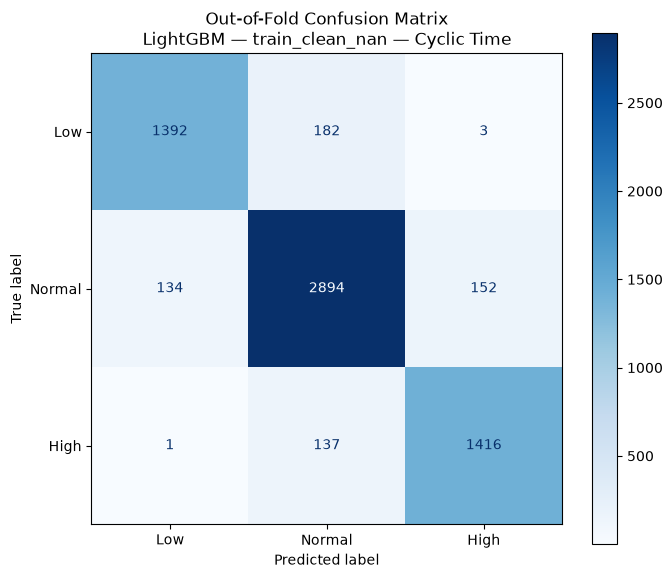

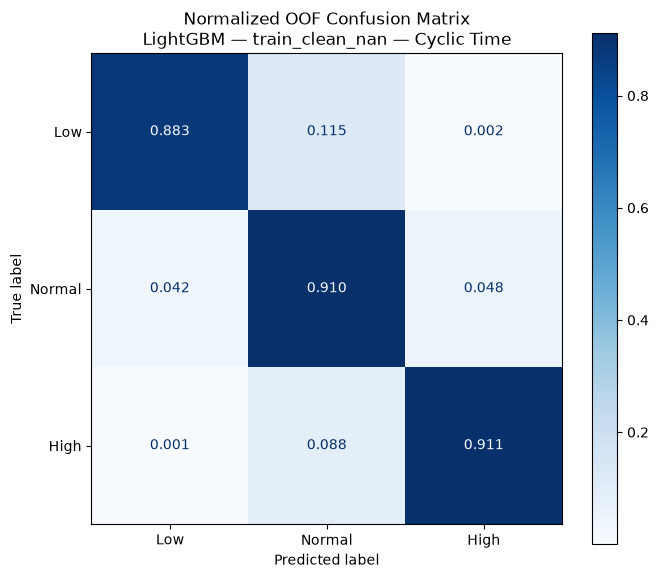


MOST COMMON ERRORS


,True Class,Predicted Class,Count
3,Low,Normal,182
4,Normal,High,152
1,High,Normal,137
5,Normal,Low,134
2,Low,High,3
0,High,Low,1



ERROR RATE BY TRUE CLASS


,True Class,Error Rate
0,High,0.0888
1,Low,0.1173
2,Normal,0.0899



OOF results:


,Demand_Category,OOF_Prediction,Correct
0,1,1,True
1,2,2,True
2,0,0,True
3,2,2,True
4,2,2,True


In [12]:
# ============================================================
# OOF PER-CLASS ERROR ANALYSIS
# Best model:
#   Dataset      = train_clean_nan
#   Model        = LightGBM
#   Preprocessing = Cyclic time:
#                   Hour + Weekday + Month + Season
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Select the exact winning dataset
# ------------------------------------------------------------

winner_df = df_train_clean_nan.copy()

print("Dataset shape:", winner_df.shape)


# ------------------------------------------------------------
# 2. Apply the exact winning preprocessing / feature engineering
# ------------------------------------------------------------

winner_df = add_skew_transformations(winner_df)
winner_df = add_weather_categories(winner_df)
winner_df = add_weekday(winner_df)
winner_df = add_month(winner_df)
winner_df = add_all_cyclic_time_features(winner_df)


# ------------------------------------------------------------
# 3. Define the exact winning features
# ------------------------------------------------------------

winner_numeric_features = SKEW_NUMERIC_FEATURES + [
    "Weekday_sin",
    "Weekday_cos",
    "Month_sin",
    "Month_cos",
    "Hour_sin",
    "Hour_cos",
    "Season_sin",
    "Season_cos",
]

winner_categorical_features = [
    "Holiday",
    "Functioning Day"
]

feature_cols = [
    c
    for c in (
        winner_numeric_features +
        winner_categorical_features
    )
    if c in winner_df.columns
]

X = winner_df[feature_cols].copy()
y = winner_df["Demand_Category"].astype(int)


# ------------------------------------------------------------
# 4. Prepare categorical columns for LightGBM
# ------------------------------------------------------------

for col in winner_categorical_features:
    if col in X.columns:
        X[col] = X[col].astype("category")


# ------------------------------------------------------------
# 5. Build the winning LightGBM model
# ------------------------------------------------------------

model = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


# ------------------------------------------------------------
# 6. Generate honest out-of-fold predictions
# ------------------------------------------------------------

oof_predictions = cross_val_predict(
    model,
    X,
    y,
    cv=CV,
    method="predict",
    n_jobs=1
)


# ------------------------------------------------------------
# 7. Overall OOF Macro-F1
# ------------------------------------------------------------

oof_macro_f1 = f1_score(
    y,
    oof_predictions,
    average="macro"
)

print("=" * 60)
print("OUT-OF-FOLD RESULTS")
print("=" * 60)

print(
    f"OOF Macro-F1: {oof_macro_f1:.4f}"
)


# ------------------------------------------------------------
# 8. Per-class classification report
# ------------------------------------------------------------

class_names = [
    "Low",
    "Normal",
    "High"
]

print("\nCLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y,
        oof_predictions,
        labels=[0, 1, 2],
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 9. Per-class metrics table
# ------------------------------------------------------------

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y,
        oof_predictions,
        labels=[0, 1, 2],
        zero_division=0
    )
)

per_class_results = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Support": support
})

per_class_results["Error Rate"] = (
    1 - per_class_results["Recall"]
)

print("\nPER-CLASS PERFORMANCE")
display(
    per_class_results.round(4)
)


# ------------------------------------------------------------
# 10. Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y,
    oof_predictions,
    labels=[0, 1, 2]
)

print("\nCONFUSION MATRIX")
print(cm)


# Raw confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title(
    "Out-of-Fold Confusion Matrix\n"
    "LightGBM — train_clean_nan — Cyclic Time"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. Normalized confusion matrix
# ------------------------------------------------------------

cm_normalized = confusion_matrix(
    y,
    oof_predictions,
    labels=[0, 1, 2],
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=".3f"
)

ax.set_title(
    "Normalized OOF Confusion Matrix\n"
    "LightGBM — train_clean_nan — Cyclic Time"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. Detailed error analysis
# ------------------------------------------------------------

oof_analysis = pd.DataFrame({
    "True Class": y.to_numpy(),
    "Predicted Class": oof_predictions
})

oof_analysis["True Class"] = (
    oof_analysis["True Class"]
    .map({
        0: "Low",
        1: "Normal",
        2: "High"
    })
)

oof_analysis["Predicted Class"] = (
    oof_analysis["Predicted Class"]
    .map({
        0: "Low",
        1: "Normal",
        2: "High"
    })
)

oof_analysis["Correct"] = (
    oof_analysis["True Class"] ==
    oof_analysis["Predicted Class"]
)


# ------------------------------------------------------------
# 13. Most common errors
# ------------------------------------------------------------

errors = oof_analysis[
    ~oof_analysis["Correct"]
]

error_summary = (
    errors
    .groupby(
        ["True Class", "Predicted Class"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values(
        "Count",
        ascending=False
    )
)

print("\nMOST COMMON ERRORS")
display(error_summary)


# ------------------------------------------------------------
# 14. Error rate by true class
# ------------------------------------------------------------

class_error_rates = (
    oof_analysis
    .groupby("True Class")["Correct"]
    .apply(lambda x: 1 - x.mean())
    .reset_index(name="Error Rate")
)

print("\nERROR RATE BY TRUE CLASS")
display(
    class_error_rates.round(4)
)


# ------------------------------------------------------------
# 15. Save OOF predictions for further analysis
# ------------------------------------------------------------

oof_results = winner_df.copy()

oof_results["OOF_Prediction"] = oof_predictions
oof_results["Correct"] = (
    winner_df["Demand_Category"].to_numpy()
    == oof_predictions
)

print("\nOOF results:")
display(
    oof_results[
        [
            "Demand_Category",
            "OOF_Prediction",
            "Correct"
        ]
    ].head()
)

## Final model, test predictions, and Kaggle submission

With the winning configuration validated above, the final step refits LightGBM on the *entire* `train_clean_nan`
training set (6,311 rows, 24 features — no train/validation split, since cross-validation has already served
that purpose) and applies the identical feature-engineering pipeline to `test.csv` before predicting.

A few submission-specific details matter here: the fitted training categories for `Holiday`/`Functioning Day`
are explicitly reused when preparing the test categorical columns, so a category present in training but
absent from a given test fold can never silently break prediction; column order and completeness are asserted
to match between train and test before fitting; and the predicted class distribution (Low 631 / Normal 1,369 /
High 628) is checked for sanity against the roughly 1:2:1 balance seen in training. The final file,
`submission_classification_lightgbm.csv`, contains `Kaggle_ID` and `Demand_Category` (encoded 0/1/2) sorted by
`Kaggle_ID`, exactly matching the competition's required submission format; a second file with human-readable
labels is saved alongside it purely for manual inspection.


In [20]:
# ============================================================
# FINAL MODEL + TEST PREDICTIONS + KAGGLE SUBMISSION
#
# Winner:
#   Dataset       = train_clean_nan
#   Model         = LightGBM
#   Preprocessing = Cyclic time:
#                   Hour + Weekday + Month + Season
# ============================================================

import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier


# ------------------------------------------------------------
# 1. Class mapping
# ------------------------------------------------------------

CLASS_MAPPING = {
    0: "Low",
    1: "Normal",
    2: "High"
}


# ------------------------------------------------------------
# 2. Training data
# ------------------------------------------------------------

winner_train = df_train_clean_nan.copy()

print("Training shape:", winner_train.shape)


# ------------------------------------------------------------
# 3. Apply EXACTLY the same feature engineering
#    used for the winning experiment
# ------------------------------------------------------------

winner_train = add_skew_transformations(winner_train)
winner_train = add_weather_categories(winner_train)
winner_train = add_weekday(winner_train)
winner_train = add_month(winner_train)
winner_train = add_all_cyclic_time_features(winner_train)


# ------------------------------------------------------------
# 4. Define the winning features
# ------------------------------------------------------------

winner_numeric_features = SKEW_NUMERIC_FEATURES + [
    "Weekday_sin",
    "Weekday_cos",
    "Month_sin",
    "Month_cos",
    "Hour_sin",
    "Hour_cos",
    "Season_sin",
    "Season_cos",
]

winner_categorical_features = [
    "Holiday",
    "Functioning Day"
]

feature_cols = [
    col
    for col in (
        winner_numeric_features +
        winner_categorical_features
    )
    if col in winner_train.columns
]


# ------------------------------------------------------------
# 5. Prepare X and y
# ------------------------------------------------------------

X_train = winner_train[feature_cols].copy()

# Model uses the numerical encoding:
# 0 = Low
# 1 = Normal
# 2 = High
y_train = winner_train["Demand_Category"].astype(int)


# LightGBM categorical features
for col in winner_categorical_features:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype("category")


print("Number of features:", len(feature_cols))
print("Features:")
print(feature_cols)


# ------------------------------------------------------------
# 6. Load test data
# ------------------------------------------------------------

df_test = pd.read_csv("test.csv")

print("\nTest shape:", df_test.shape)


# ------------------------------------------------------------
# 7. Apply EXACTLY the same feature engineering to test
# ------------------------------------------------------------

test_exp = df_test.copy()

test_exp = add_skew_transformations(test_exp)
test_exp = add_weather_categories(test_exp)
test_exp = add_weekday(test_exp)
test_exp = add_month(test_exp)
test_exp = add_all_cyclic_time_features(test_exp)


# ------------------------------------------------------------
# 8. Prepare X_test
# ------------------------------------------------------------

X_test = test_exp[feature_cols].copy()


# ------------------------------------------------------------
# 9. Make categorical columns compatible with training
# ------------------------------------------------------------

for col in winner_categorical_features:
    if col in X_test.columns:

        X_test[col] = pd.Categorical(
            X_test[col],
            categories=X_train[col].cat.categories
        )


# ------------------------------------------------------------
# 10. Sanity checks
# ------------------------------------------------------------

print("\nTraining columns:")
print(list(X_train.columns))

print("\nTest columns:")
print(list(X_test.columns))

assert list(X_train.columns) == list(X_test.columns)
assert len(X_test) == len(df_test)

print("\nRemaining missing values in test:")

display(
    X_test.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)


# ------------------------------------------------------------
# 11. Fit FINAL LightGBM model
# ------------------------------------------------------------

final_model = LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


print("\nTraining final LightGBM model...")

final_model.fit(
    X_train,
    y_train,
    categorical_feature=[
        col
        for col in winner_categorical_features
        if col in X_train.columns
    ]
)

print("Training complete.")


# ------------------------------------------------------------
# 12. Predict test set
# ------------------------------------------------------------

test_predictions = final_model.predict(X_test)

test_predictions = (
    np.asarray(test_predictions)
    .astype(int)
    .ravel()
)


# ------------------------------------------------------------
# 13. Convert numerical predictions to labels
# ------------------------------------------------------------

test_prediction_labels = pd.Series(
    test_predictions
).map(CLASS_MAPPING)


# ------------------------------------------------------------
# 14. Prediction sanity checks
# ------------------------------------------------------------

print("\nPrediction distribution:")

prediction_distribution = pd.DataFrame({
    "Encoded": test_predictions,
    "Label": test_prediction_labels
})

display(
    prediction_distribution
    .value_counts()
    .rename("Count")
    .reset_index()
    .sort_values("Encoded")
)

assert len(test_predictions) == len(df_test)

assert set(
    np.unique(test_predictions)
).issubset({0, 1, 2})

assert set(
    test_prediction_labels.dropna().unique()
).issubset({
    "Low",
    "Normal",
    "High"
})


# ------------------------------------------------------------
# 15. Create a submission dataframe
#
# Keep BOTH versions:
#   Demand_Category      -> official encoded Kaggle value
#   Demand_Category_Label -> human-readable label
# ------------------------------------------------------------

submission = pd.DataFrame({
    "Kaggle_ID": df_test["Kaggle_ID"],
    "Demand_Category": test_predictions,
    "Demand_Category_Label": test_prediction_labels
})


# ------------------------------------------------------------
# 16. Sort by Kaggle ID
# ------------------------------------------------------------

submission = (
    submission
    .sort_values("Kaggle_ID")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 17. Final checks
# ------------------------------------------------------------

assert submission["Kaggle_ID"].isna().sum() == 0
assert submission["Demand_Category"].isna().sum() == 0
assert submission["Demand_Category_Label"].isna().sum() == 0

assert set(
    submission["Demand_Category"].unique()
).issubset({0, 1, 2})

assert set(
    submission["Demand_Category_Label"].unique()
).issubset({
    "Low",
    "Normal",
    "High"
})


print("\nSubmission preview:")
display(submission.head(10))


# ------------------------------------------------------------
# 18. Save human-readable prediction file
# ------------------------------------------------------------

submission_with_labels_path = (
    "classification_predictions_lightgbm_with_labels.csv"
)

submission.to_csv(
    submission_with_labels_path,
    index=False
)

print(
    f"\nSaved prediction file with labels to:\n"
    f"{submission_with_labels_path}"
)


# ------------------------------------------------------------
# 19. Create the OFFICIAL Kaggle submission
#
# The project instructions specify:
#   Kaggle ID
#   Demand Category
#
# with values 0, 1, or 2.
# ------------------------------------------------------------

kaggle_submission = submission[
    [
        "Kaggle_ID",
        "Demand_Category"
    ]
].copy()


kaggle_submission_path = (
    "submission_classification_lightgbm.csv"
)

kaggle_submission.to_csv(
    kaggle_submission_path,
    index=False
)


print(
    f"\nOfficial Kaggle submission saved to:\n"
    f"{kaggle_submission_path}"
)


# ------------------------------------------------------------
# 20. Show final files
# ------------------------------------------------------------

print("\nOfficial Kaggle submission:")
display(
    kaggle_submission.head(10)
)

Training shape: (6311, 17)
Number of features: 24
Features:
['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Wind speed_log1p', 'Solar Radiation_log1p', 'Rainfall_log1p', 'Snowfall_log1p', 'Visibility_pow3', 'Weekday_sin', 'Weekday_cos', 'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos', 'Season_sin', 'Season_cos', 'Holiday', 'Functioning Day']

Test shape: (2628, 15)

Training columns:
['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Wind speed_log1p', 'Solar Radiation_log1p', 'Rainfall_log1p', 'Snowfall_log1p', 'Visibility_pow3', 'Weekday_sin', 'Weekday_cos', 'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos', 'Season_sin', 'Season_cos', 'Holiday', 'Functioning Day']

Test columns:
['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall', 'Wind spee

Hour                     0
Temperature              0
Humidity                 0
Wind speed               0
Visibility               0
Dew point temperature    0
Solar Radiation          0
Rainfall                 0
Snowfall                 0
Wind speed_log1p         0
Solar Radiation_log1p    0
Rainfall_log1p           0
Snowfall_log1p           0
Visibility_pow3          0
Weekday_sin              0
Weekday_cos              0
Month_sin                0
Month_cos                0
Hour_sin                 0
Hour_cos                 0
dtype: int64


Training final LightGBM model...
Training complete.

Prediction distribution:


,Encoded,Label,Count
1,0,Low,631
0,1,Normal,1369
2,2,High,628



Submission preview:


,Kaggle_ID,Demand_Category,Demand_Category_Label
0,0,1,Normal
1,1,1,Normal
2,2,1,Normal
3,3,1,Normal
4,4,1,Normal
5,5,0,Low
6,6,0,Low
7,7,1,Normal
8,8,1,Normal
9,9,1,Normal



Saved prediction file with labels to:
classification_predictions_lightgbm_with_labels.csv

Official Kaggle submission saved to:
submission_classification_lightgbm.csv

Official Kaggle submission:


,Kaggle_ID,Demand_Category
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1
5,5,0
6,6,0
7,7,1
8,8,1
9,9,1
